# Pandas Assignment — Temperature Sensor Analysis

**Instructions:**
- Read each question **carefully before running any code cell**
- Write your answers in the `[YOUR ANSWER]` cells — these require written explanations, not just code
- Some code cells are intentionally left blank: you need to write the code yourself
- Focus on *why* things work, not just *what* to type

**Estimated time:** ~70 minutes

---
## Part 1 — Get to Know the Dataset (15 min)

You have been given a new dataset: `assignment_data.csv`.  
It contains measurements recorded by a temperature sensor in a lab environment.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('assignment_data.csv')
df

,time_s,temperature_C
0,0.00,26.226
1,0.01,20.835
2,0.02,22.082
3,0.03,23.019
4,0.04,20.028
...,...,...
1995,19.95,25.491
1996,19.96,26.951
1997,19.97,22.885
1998,19.98,21.358


**Q1.1** — Before using any pandas function, just from looking at the column names and the first few rows:
- What does each column represent?
- What unit does each column likely use?
- How often is the sensor sampling, in Hz? *(Hint: look at the time step between consecutive rows)*

> **[time_s , time in seconds, steps by 0.01 s , sensor samples at 100 Hz
temperature_C , temperature in °C]**

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time_s         2000 non-null   float64
 1   temperature_C  1982 non-null   float64
dtypes: float64(2)
memory usage: 31.4 KB


In [12]:
#df.describe()

**Q1.2** — Look at the output of `df.info()` and `df.describe()` together:
- How many missing values are there in `temperature_C`? *(Hint: compare Non-Null Count to the total number of rows)*
- What is the maximum temperature recorded? Is that a realistic lab temperature? What do you suspect about those readings?

> **[Missing values: info shows 1982 non-null out of 2000 rows 18 missing values
Max temp: 84°C  not realistic for a lab (normal is 18–30°C). Those are likely sensor glitches/errors, not real readings.]**

In [13]:
df.isna().sum()

time_s            0
temperature_C    18
dtype: int64

**Q1.3** — Write a **single line of code** below to display only the rows where `temperature_C` is greater than 50.  
How many rows are there?

In [15]:
# YOUR CODE HERE
df[df['temperature_C'] > 50]

,time_s,temperature_C
261,2.61,69.098
717,7.17,64.090
728,7.28,73.082
743,7.43,70.984
1322,13.22,70.786


**Q1.4** — Based on what you found above:
- What percentage of the 2000 rows do these high-temperature readings represent?

we have 2000 rows, compared to there which are filtered out by more than 50C, so i think we should divided 5/2000, which is 0.25
- Do you think they are real measurements or sensor errors? Justify your reasoning.
either some sort of emergency happened in the lab or they are errors, because tempreatures dont jump that high for no reason.

> **[YOUR ANSWER 1.4]**

---
## Part 2 — Handling Missing Data (15 min)

**Q2.1** — **Before writing any code**, think about this scenario:  
If you use `df.fillna(0)` to replace the missing temperature values with 0:
- What temperature does 0 represent in Celsius?
- Is that a realistic lab temperature?
- What problem would this introduce when you later compute the mean?

> **[YOUR ANSWER 2.1]**

In [ ]:
# Strategy A: drop rows with missing values
df_dropped = df.dropna()
print("Rows remaining after dropna():", len(df_dropped))
print("Rows lost:", len(df) - len(df_dropped))

In [ ]:
# Strategy B: fill missing values with the column mean
mean_temp = df['temperature_C'].mean()
df_filled = df.fillna(mean_temp)
print("Mean used to fill:", round(mean_temp, 3))
print("Missing values remaining:", df_filled['temperature_C'].isna().sum())

**Q2.2** — Compare the two strategies:
- Strategy A loses rows. Is losing roughly 1% of the data acceptable here? What could you lose along with it?
**Losing 1% is fine, but you might delete readings from an important moment in time.**
- Strategy B keeps all rows but replaces NaN with an estimate. Does that introduce any distortion into the data?
**Tiny distortion , replacing a few missing values with the mean won't noticeably change anything.**
- Which strategy would you choose for this dataset, and why?
**Strategy B — because it keeps all rows and time steps intact, better for rolling averages later.**



In [16]:
# Apply your chosen strategy — change this if you prefer dropna()
df_clean = df.fillna(df['temperature_C'].mean())
print("Working dataset has", len(df_clean), "rows")

Working dataset has 2000 rows


---
## Part 3 — Visualise and Interpret (15 min)

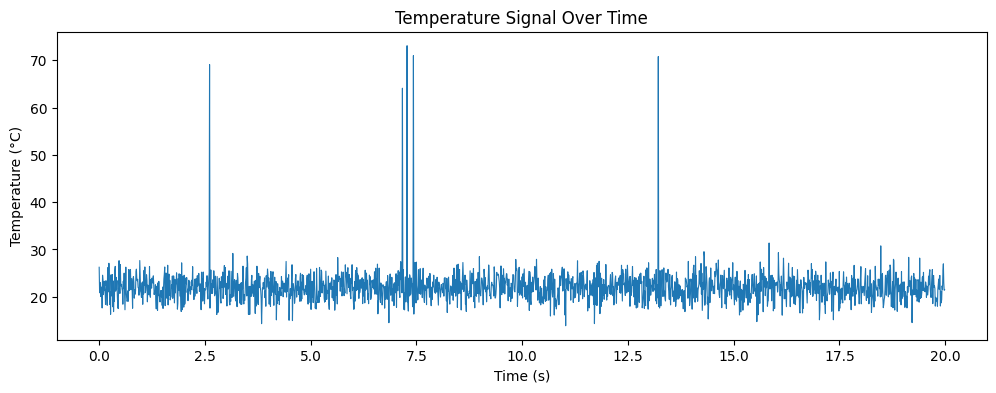

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], linewidth=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Signal Over Time')
plt.show()

**Q3.1** — Describe what you see in the plot:

- Is the signal noisy or smooth?
**Signal is noisy**

- Are there any obvious spikes or sudden jumps?
**Yes, around 2.5, 7.5, 13, there are sudden spikes**

- Does the signal appear to increase, decrease, or stay roughly constant over time?
**Signal stays around the same aound 22 degrees , other than sudden spikes stays roughly constant**



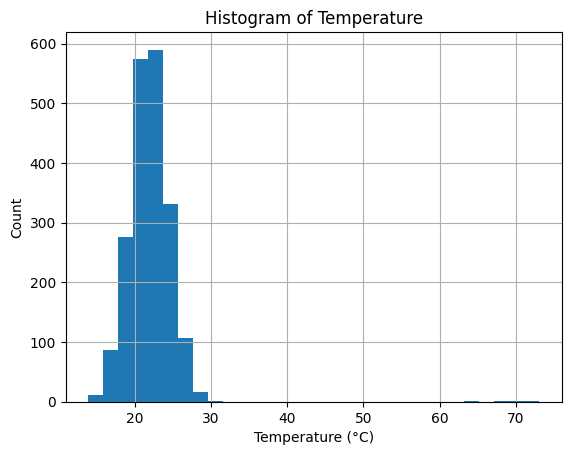

In [18]:
df_clean['temperature_C'].hist(bins=30)
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Histogram of Temperature')
plt.show()

**Q3.2** — Look at the histogram:
- Is the main distribution roughly symmetric, or skewed?


**I would say roughly symmetric, looks like burj khalifa**


- Do you see an isolated cluster of bars far to the right? What do those correspond to?


**yes, this corresponds to outlier readings.**


- If you removed those outlier readings, how would the histogram change?


**it would all be around 22 degrees i think**

> **[YOUR ANSWER 3.2]**

**Q3.3** — **Before running the cell below**, make a prediction:  
Given that the dataset contains a few very high temperature outliers, do you expect the mean to be **higher than**, **lower than**, or **about the same as** the median?  
Write your prediction and your reasoning first, then run the code to check.

> **[i think the oulier will make the mean higher a bit, but the median will be roughly the same]**

In [19]:
# YOUR CODE HERE
print("Mean:  ", df_clean['temperature_C'].mean())
print("Median:", df_clean['temperature_C'].median())

Mean:   22.02786881937437
Median: 21.958


**Q3.4** — Was your prediction correct?  
In one sentence, explain *why* the mean and median behave differently when outliers are present.

> **[yes it was correct, because mean is higher than median exactly because of the outliers.]**

---
## Part 4 — Smoothing the Signal (15 min)

A rolling average smooths a noisy signal by replacing each value with the average of the surrounding samples.  
You control how much smoothing by choosing the **window size** (number of samples used per average).

**Q4.1** — **Before running any code**, use the sampling rate to reason about window sizes:  
The sensor samples at 100 Hz (100 samples per second).
- What time duration (in seconds) does a window of 10 samples represent?



10/100 = 0.1

- What time duration does a window of 200 samples represent?

200/100 = 2

> **[10/100 = 0.1
 200/100 = 2 ]**

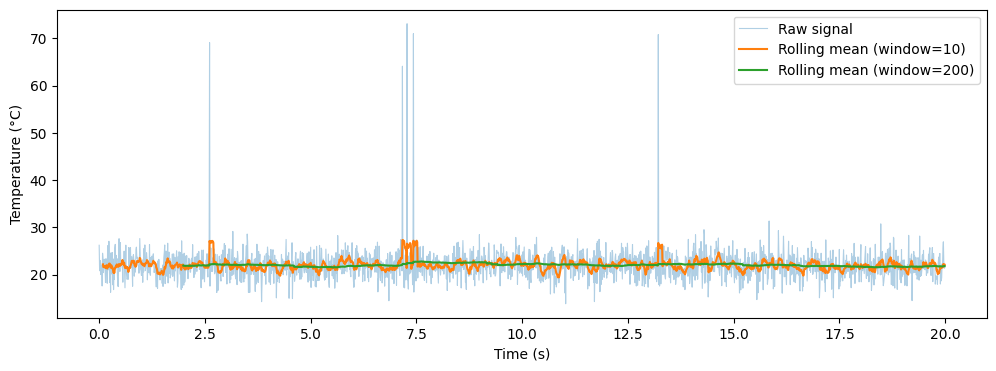

In [20]:
df_clean['rolling_10'] = df_clean['temperature_C'].rolling(window=10).mean()
df_clean['rolling_200'] = df_clean['temperature_C'].rolling(window=200).mean()

plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], alpha=0.35, linewidth=0.8, label='Raw signal')
plt.plot(df_clean['time_s'], df_clean['rolling_10'], linewidth=1.5, label='Rolling mean (window=10)')
plt.plot(df_clean['time_s'], df_clean['rolling_200'], linewidth=1.5, label='Rolling mean (window=200)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

**Q4.2** — Compare the two smoothed signals in the plot:
- Which one tracks the raw signal more closely?
- Which one produces the smoother result?
- At the very beginning of the plot, why does `rolling_200` start later than `rolling_10`?

> **[window=10 tracks the raw signal more closely ,     window=200 produces the smoother result.     , rolling_200 starts later because it needs 200 samples before it can compute its first average that's like 2 seconds of data before it starts kicking in ]**

In [21]:
print("Std of raw signal:    ", round(df_clean['temperature_C'].std(), 4))
print("Std of rolling_10:    ", round(df_clean['rolling_10'].std(), 4))
print("Std of rolling_200:   ", round(df_clean['rolling_200'].std(), 4))

Std of raw signal:     3.4296
Std of rolling_10:     1.0539
Std of rolling_200:    0.2726


**Q4.3** — The standard deviation decreases as the window gets larger.  
Imagine you are building an alarm system that must detect a **sudden large temperature spike** within 0.5 seconds of it happening.  
- Would you use a small or large rolling window? Why?  


**Small window ofcourse,  a large window averages the spike with many normal readings around it, diluting it  the alarm would trigger too late or not at all.**


- What do you *trade away* by using a larger window?

**small window keeps noise, so you get more false alarms from random fluctuations.**



---
## Part 5 — Outlier Investigation (10 min)

**Q5.1** — Write code below to:
1. Count how many rows have `temperature_C > 50`
2. Compute what percentage of the total dataset that represents (round to 2 decimal places)

Print both values with clear labels.

In [22]:
# YOUR CODE HERE
count = (df_clean['temperature_C'] > 50).sum()
pct = round(count / len(df_clean) * 100, 2)
print("Count:", count)
print("Percentage:", pct, "%")

Count: 5
Percentage: 0.25 %


In [23]:
# Mean and median WITH outliers
mean_with = df_clean['temperature_C'].mean()
median_with = df_clean['temperature_C'].median()

# Mean and median WITHOUT outliers
df_no_outliers = df_clean[df_clean['temperature_C'] <= 50]
mean_without = df_no_outliers['temperature_C'].mean()
median_without = df_no_outliers['temperature_C'].median()

print(f"Mean     WITH outliers: {mean_with:.3f}")
print(f"Mean  WITHOUT outliers: {mean_without:.3f}")
print()
print(f"Median   WITH outliers: {median_with:.3f}")
print(f"Median WITHOUT outliers: {median_without:.3f}")

Mean     WITH outliers: 22.028
Mean  WITHOUT outliers: 21.909

Median   WITH outliers: 21.958
Median WITHOUT outliers: 21.952


**Q5.2** — Look at the numbers above:
- Which statistic changed more when outliers were removed — the mean or the median?
- In one sentence, explain *why* the median is more resistant to outliers than the mean.

> **[The mean changed more 21.909 -> 22.028 The median only depends on the middle value, so extreme outliers at the edges can't shift it much.]**

**Q5.3** — Imagine you are a lab technician reviewing this data.  
Give **one reason why you might remove** the outliers and **one reason why you might keep** them.

> **[One reason i might remove them is it might kess up data. But a reason i would keep them is because they are real ecords and data, removing htem would make me untrusted.]**

---
## Bonus — Putting It All Together *(optional)*

Using everything you have learned, create a **single, well-labelled plot** that shows:
- The raw signal (with low opacity)
- The smoothed signal using the window size you think is most appropriate
- Two horizontal lines: one for the mean and one for the median of the clean signal *(without outliers)*

Add a title, axis labels, and a legend. No written answer required — make it clear and informative.

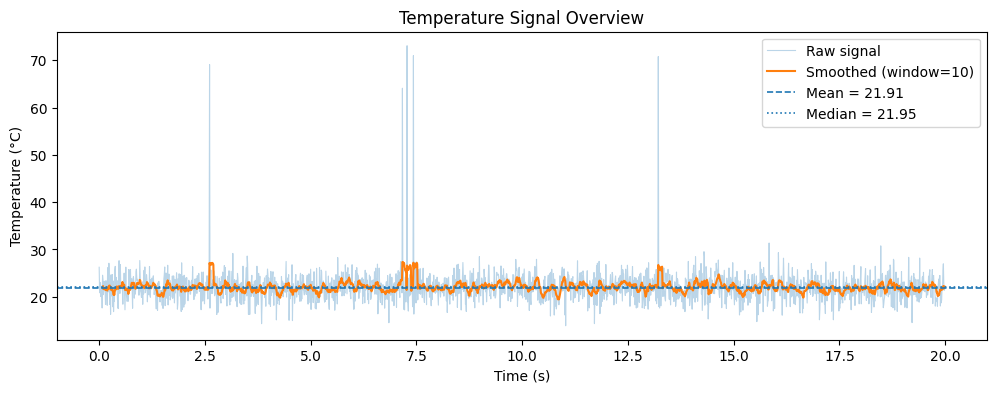

In [24]:
# YOUR CODE HERE
df_no_outliers = df_clean[df_clean['temperature_C'] <= 50]
mean_clean = df_no_outliers['temperature_C'].mean()
median_clean = df_no_outliers['temperature_C'].median()

plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], alpha=0.3, linewidth=0.8, label='Raw signal')
plt.plot(df_clean['time_s'], df_clean['rolling_10'], linewidth=1.5, label='Smoothed (window=10)')
plt.axhline(mean_clean, linestyle='--', linewidth=1.2, label=f'Mean = {mean_clean:.2f}')
plt.axhline(median_clean, linestyle=':', linewidth=1.2, label=f'Median = {median_clean:.2f}')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Signal Overview')
plt.legend()
plt.show()